# Create Figure 1 and perform associated statistical analyses

### Notebook structure

* load libraries
* define functions for plotting and bootstrapping, etc.
* load data and perform minor pre-processing
* Render main text figure panels and perform statistical tests

### Main text Figure 1

* Figure 1a: The Yeast Interactome PPI network (NetworkX) with annotations labelled
* Figure 1b: Histogram of yeast meltome interaction data for ANYI dataset & all yeast proteins 
    *  Median from entire dataset and ANYI subset with R2 >= 0.9 with 95% CIs
* Figure 1c: Melting point for phospho/non-phospho proteins

### Load libraries

In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.transforms import ScaledTranslation
from tqdm import tqdm, trange
import numpy as np
import networkx as nx
import pandas as pd
from scipy.stats import mannwhitneyu
from scipy.stats import fisher_exact
from itertools import combinations
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from typing import Dict

### Load functions

In [15]:
# function to generate a nice, reproducible network visualization
def plot_high_quality_network(
    G,
    title,
    color,
    save_name,
    legend_label,
    node_size=12,
    component_compression=0.4,
    border_frac=0.05,
    k=0.2,
    edge_width_scale=2.5,
):
    fig, ax = plt.subplots(figsize=(3.5, 3.5))

    # color variants
    base_color = mcolors.to_rgb(color)
    dark_color = tuple(np.clip(np.array(base_color) * 0.7, 0, 1))
    bright_color = tuple(np.clip(np.array(base_color) * 1.2, 0, 1))

    # --- 1. Base layout ---
    pos = nx.spring_layout(G, seed=42, k=k, iterations=100)

    # --- 2. Component compression (unchanged) ---
    G_und = G if not G.is_directed() else G.to_undirected()
    components = list(nx.connected_components(G_und))

    node_to_comp = {}
    for cid, comp in enumerate(components):
        for n in comp:
            node_to_comp[n] = cid

    comp_centroids = {}
    for cid, comp in enumerate(components):
        xs = [pos[n][0] for n in comp]
        ys = [pos[n][1] for n in comp]
        comp_centroids[cid] = np.array([np.mean(xs), np.mean(ys)])

    all_centroids = np.vstack(list(comp_centroids.values()))
    global_centroid = all_centroids.mean(axis=0)

    f = component_compression

    new_pos = {}
    for cid, comp in enumerate(components):
        old_centroid = comp_centroids[cid]
        new_centroid = global_centroid + f * (old_centroid - global_centroid)
        shift = new_centroid - old_centroid
        for n in comp:
            new_pos[n] = pos[n] + shift

    pos = new_pos

    # --- 3. Normalize AND add border padding in data space ---
    xs = np.array([p[0] for p in pos.values()])
    ys = np.array([p[1] for p in pos.values()])
    min_x, max_x = xs.min(), xs.max()
    min_y, max_y = ys.min(), ys.max()
    span_x = max_x - min_x if max_x > min_x else 1.0
    span_y = max_y - min_y if max_y > min_y else 1.0

    # map into [border_frac, 1 - border_frac] instead of [0, 1]
    inner_scale_x = 1 - 2 * border_frac
    inner_scale_y = 1 - 2 * border_frac

    for n in pos:
        x, y = pos[n]
        x_norm = (x - min_x) / span_x
        y_norm = (y - min_y) / span_y
        pos[n] = (
            border_frac + inner_scale_x * x_norm,
            border_frac + inner_scale_y * y_norm,
        )

    # --- 4. Draw edges ---
    edges = np.array(list(G.edges()))
    np.random.shuffle(edges)
    n_edges = len(edges)
    alphas = np.linspace(0.05, 0.25, n_edges)
    widths = np.linspace(0.1, 0.8, n_edges) * edge_width_scale

    for i, (u, v) in enumerate(edges):
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        ax.plot(
            [x0, x1],
            [y0, y1],
            color=color,
            lw=widths[i],
            alpha=alphas[i],
            solid_capstyle="round",
            zorder=i,
        )

    # --- 5. Draw nodes ---
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_size=node_size,
        node_color=bright_color,
        alpha=0.9,
        linewidths=0.4,
        edgecolors='black'
    )


    # --- 6. Axes settings: include the padding region ---
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.axis("off")

    if title:
        ax.set_title(title)

    plt.tight_layout()
    plt.savefig(save_name, bbox_inches="tight", facecolor="white", dpi=1000)
    plt.show()

# convert raw output from bootstrapping into a lower and upper CI
def percentile_ci(x, alpha=0.05):
    """Return (lower, upper) percentile CI."""
    lower, upper = np.percentile(x, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return lower, upper

# -----------------------------
# Bootstrap: one loop over B; collects multiple stats per resample
# -----------------------------
def bootstrap_ci_stats(values, B=50_000, ci=95, random_state=27, show_progress=True):
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    n = len(vals)

    out = {
        "n": n,
        "mean": np.nan, "mean_ci_low": np.nan, "mean_ci_high": np.nan,
        "median": np.nan, "median_ci_low": np.nan, "median_ci_high": np.nan,
        "min": np.nan, "min_ci_low": np.nan, "min_ci_high": np.nan,
        "max": np.nan, "max_ci_low": np.nan, "max_ci_high": np.nan,
    }
    if n == 0:
        return out

    rng = np.random.default_rng(random_state)

    means   = np.empty(B, dtype=float)
    medians = np.empty(B, dtype=float)
    mins    = np.empty(B, dtype=float)
    maxs    = np.empty(B, dtype=float)

    iterator = trange(B, desc="Bootstrapping", disable=(not show_progress))
    for b in iterator:
        sample = rng.choice(vals, size=n, replace=True)
        means[b]   = np.mean(sample)
        medians[b] = np.median(sample)
        mins[b]    = np.min(sample)
        maxs[b]    = np.max(sample)

    alpha = 100 - ci

    out["mean"]   = float(np.mean(vals))
    out["median"] = float(np.median(vals))
    out["min"]    = float(np.min(vals))
    out["max"]    = float(np.max(vals))

    out["mean_ci_low"], out["mean_ci_high"] = np.percentile(means,   [alpha/2, 100 - alpha/2]).tolist()
    out["median_ci_low"], out["median_ci_high"] = np.percentile(medians, [alpha/2, 100 - alpha/2]).tolist()
    out["min_ci_low"], out["min_ci_high"] = np.percentile(mins,    [alpha/2, 100 - alpha/2]).tolist()
    out["max_ci_low"], out["max_ci_high"] = np.percentile(maxs,    [alpha/2, 100 - alpha/2]).tolist()

    return out


# -----------------------------
# Subset definitions
# -----------------------------
def make_meltome_subsets(nodes: pd.DataFrame, r2_thresh: float = 0.90):
    required = ["meltome-melting-point", "meltome-fit-R2", "hub", "phosphorylated"]
    missing = [c for c in required if c not in nodes.columns]
    if missing:
        raise KeyError(f"nodes is missing required columns: {missing}")

    df = nodes.copy()
    df["meltome-melting-point"] = pd.to_numeric(df["meltome-melting-point"], errors="coerce")
    df["meltome-fit-R2"] = pd.to_numeric(df["meltome-fit-R2"], errors="coerce")

    # Keep as booleans
    df["hub"] = df["hub"].astype(bool)
    df["phosphorylated"] = df["phosphorylated"].astype(bool)

    base = df[(df["meltome-fit-R2"] >= r2_thresh) & (df["meltome-melting-point"].notna())].copy()

    subsets = {
        "1_all_filtered": base,
        "2_hubs": base[base["hub"]],
        "3_non_hubs": base[~base["hub"]],
        "4_phosphorylated": base[base["phosphorylated"]],
        "5_not_phosphorylated": base[~base["phosphorylated"]],
        "6_phospho_and_hub": base[base["phosphorylated"] & base["hub"]],
        "7_not_phospho_and_hub": base[(~base["phosphorylated"]) & base["hub"]],
        "8_phospho_and_nonhub": base[base["phosphorylated"] & (~base["hub"])],
        "9_not_phospho_and_nonhub": base[(~base["phosphorylated"]) & (~base["hub"])],
    }
    
    return subsets


def summarize_meltome_by_subset(nodes: pd.DataFrame, B=50_000, ci=95, r2_thresh=0.90, random_state=27, show_progress=True):
    subsets = make_meltome_subsets(nodes, r2_thresh=r2_thresh)

    rows = []
    for name, df_sub in subsets.items():
        vals = df_sub["meltome-melting-point"].to_numpy()
        stats = bootstrap_ci_stats(vals, B=B, ci=ci, random_state=random_state, show_progress=show_progress)
        rows.append({"category": name, **stats})

    summary = pd.DataFrame(rows).set_index("category")
    summary = summary.loc[list(subsets.keys())]  # preserve order
    return summary, subsets


# -----------------------------
# Plot: jittered points + median + 95% CI error bars
# -----------------------------
def plot_meltome_median_ci(subsets: dict, summary_df: pd.DataFrame, jitter_sd: float = 0.08, alpha_points: float = 0.35, fontsize: int = 14):
    
    fs = fontsize
    names = list(subsets.keys())
    x = np.arange(len(names))

    fig, ax = plt.subplots(figsize=(10, 4))

    rng = np.random.default_rng(27)

    # ccatter (light grey) + median (dark grey) + CI (black)
    for i, name in enumerate(names):
        y = subsets[name]["meltome-melting-point"].to_numpy(dtype=float)
        y = y[np.isfinite(y)]
        if len(y) == 0:
            continue

        x_j = rng.normal(loc=x[i], scale=jitter_sd, size=len(y))
        ax.scatter(x_j, y, s=16, alpha=alpha_points, color="lightgrey", edgecolors="none", zorder=1)

        med = summary_df.loc[name, "median"]
        lo  = summary_df.loc[name, "median_ci_low"]
        hi  = summary_df.loc[name, "median_ci_high"]

        ax.errorbar(
            x[i], med,
            yerr=[[med - lo], [hi - med]],
            fmt="o",
            markersize=5,
            color="dimgray",      # median circle
            ecolor="black",       # CI
            elinewidth=1.5,
            capsize=4,
            zorder=2,
        )

    label_map = {
        "1_all_filtered": "All (R² ≥ 0.90)",
        "2_hubs": "Hubs",
        "3_non_hubs": "Non-hubs",
        "4_phosphorylated": "Phosphorylated",
        "5_not_phosphorylated": "Non-phosphorylated",
        "6_phospho_and_hub": "Hub &\nphosphorylated",
        "7_not_phospho_and_hub": "Hub &\nnon-phosphorylated",
        "8_phospho_and_nonhub": "Non-hub &\nphosphorylated",
        "9_not_phospho_and_nonhub": "Non-hub &\nnon-phosphorylated",
    }
    
    ax.set_xticks(x)

    tick_labels = [label_map[n] for n in names]   # map each key -> pretty label
    spine_lw = 1.75
    tick_lw  = 1.75
    tick_len = 6
    ax.set_xticklabels(tick_labels, rotation=35, ha="right", fontsize=fs)
    ax.set_ylabel("Melting point (°C)", fontsize=fs)
    ax.set_yticklabels([40, 45, 50, 55, 60, 65, 70], fontsize=fs)
    ax.set_ylim(39, 66)
    #ax.set_title("Meltome melting points by category (points = jitter; dot = median; bars = 95% bootstrap CI)")
    ax.tick_params(axis="both", which="both",
               width=tick_lw, length=tick_len,
               labelsize=fs, pad=3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(spine_lw)
    ax.spines["bottom"].set_linewidth(spine_lw)

    plt.tight_layout()
    plt.savefig("1c.pdf", dpi=300)
    plt.show()


# -----------------------------
# Pairwise Mann–Whitney U tests + BH-FDR
# -----------------------------
def pairwise_mwu_tests(subsets: dict, value_col: str = "meltome-melting-point", alternative: str = "two-sided"):
    """
    Computes all pairwise MWU tests across subsets.
    Applies Benjamini-Hochberg FDR across the full set of pairwise tests.
    Returns a long-form DataFrame suitable for heatmap pivoting later.
    """
    names = list(subsets.keys())
    comparisons = {0:['2_hubs', '3_non_hubs'], 
                   1:['4_phosphorylated', '5_not_phosphorylated'], 
                   2:['6_phospho_and_hub', '7_not_phospho_and_hub'], 
                   3:['6_phospho_and_hub', '8_phospho_and_nonhub'], 
                   4:['6_phospho_and_hub', '9_not_phospho_and_nonhub'], 
                   5:['7_not_phospho_and_hub', '8_phospho_and_nonhub'], 
                   6:['7_not_phospho_and_hub', '9_not_phospho_and_nonhub'], 
                   7:['8_phospho_and_nonhub', '9_not_phospho_and_nonhub']}
    results = []

    for key in comparisons:
        a, b = comparisons[key][0], comparisons[key][1]
        xa = subsets[a][value_col].to_numpy(dtype=float)
        xb = subsets[b][value_col].to_numpy(dtype=float)
        xa = xa[np.isfinite(xa)]
        xb = xb[np.isfinite(xb)]

        if len(xa) == 0 or len(xb) == 0:
            U, p = np.nan, np.nan
        else:
            # mannwhitneyu returns the U statistic; two-sided p-value when alternative="two-sided"
            U, p = mannwhitneyu(xa, xb, alternative=alternative, method="auto")

        results.append({
            "group_a": a,
            "group_b": b,
            "n_a": len(xa),
            "n_b": len(xb),
            "U": U,
            "p_value": p,
        })

    tests_df = pd.DataFrame(results)

    # BH-FDR across all valid p-values
    mask = tests_df["p_value"].notna()
    pvals = tests_df.loc[mask, "p_value"].to_numpy()

    if pvals.size:
        reject, p_adj, _, _ = multipletests(pvals, alpha=0.05, method="fdr_bh")
        tests_df.loc[mask, "p_adj_bh"] = p_adj
        tests_df.loc[mask, "reject_fdr_0.05"] = reject
    else:
        tests_df["p_adj_bh"] = np.nan
        tests_df["reject_fdr_0.05"] = False

    return tests_df


def make_symmetric_pvalue_matrix(tests_df: pd.DataFrame, value_col: str = "p_adj_bh"):
    """
    Convenience for later heatmaps. Produces a symmetric matrix with NaN diagonal.
    """
    names = pd.unique(pd.concat([tests_df["group_a"], tests_df["group_b"]], ignore_index=True))
    mat = pd.DataFrame(np.nan, index=names, columns=names, dtype=float)

    for _, r in tests_df.iterrows():
        a, b = r["group_a"], r["group_b"]
        mat.loc[a, b] = r[value_col]
        mat.loc[b, a] = r[value_col]

    np.fill_diagonal(mat.values, np.nan)
    return mat

def plot_fdr_heatmap(
    tests_df: pd.DataFrame,
    label_map: dict,
    alpha_fdr: float = 0.05,
    use_col: str = "p_adj_bh",
    figsize=(9, 8),
    show_values: bool = False,   # set True if you want to annotate cells
    value_fmt: str = "{:.2g}",   # formatting for annotations
):
    """
    Publication-quality heatmap of pairwise FDR-adjusted p-values.
    - Non-significant cells (p_adj >= alpha_fdr) are left white.
    - Significant cells are colored by -log10(p_adj) using a colorblind-friendly colormap.
    - Uses only matplotlib (no seaborn).

    tests_df columns expected: group_a, group_b, p_adj_bh (or use_col).
    """
    # Preserve the intended category order
    keys = list(label_map.keys())
    n = len(keys)

    # Build symmetric matrix of adjusted p-values
    pmat = pd.DataFrame(np.nan, index=keys, columns=keys, dtype=float)
    for _, r in tests_df.iterrows():
        a, b = r["group_a"], r["group_b"]
        p = r.get(use_col, np.nan)
        if (a in pmat.index) and (b in pmat.columns):
            pmat.loc[a, b] = p
            pmat.loc[b, a] = p

    # Mask diagonal
    np.fill_diagonal(pmat.values, np.nan)

    # Compute values for coloring: -log10(p_adj) for significant only; otherwise NaN (white)
    vals = pmat.to_numpy()
    sig_mask = np.isfinite(vals) & (vals < alpha_fdr)

    # Avoid log(0) if extremely small p-values
    eps = np.finfo(float).tiny
    heat = np.full_like(vals, np.nan, dtype=float)
    heat[sig_mask] = -np.log10(np.maximum(vals[sig_mask], eps))

    # Choose a colorblind-accessible sequential colormap; NaNs will be white
    cmap = plt.get_cmap("viridis").copy()
    cmap.set_bad(color="white")  # non-significant (and diagonal) white

    # Set sensible color limits based on significant values only
    finite_heat = heat[np.isfinite(heat)]
    if finite_heat.size == 0:
        vmin, vmax = 0.0, 1.0
    else:
        vmin = 0.0
        vmax = float(np.nanmax(finite_heat))

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(heat, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest", aspect="equal")

    # Ticks + labels (pretty)
    pretty = [label_map[k] for k in keys]
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(pretty)
    ax.set_yticklabels(pretty)

    # Improve readability of tick labels
    ax.tick_params(axis="x", bottom=True, top=False, labelbottom=True)
    plt.setp(ax.get_xticklabels(), rotation=70)
    dx, dy = -5, 0
    offset = ScaledTranslation(dx / fig.dpi, dy / fig.dpi, fig.dpi_scale_trans)

    # apply offset to all xticklabels
    for label in ax.xaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + offset)

    # Light gridlines to delineate cells (publication-friendly)
    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which="minor", color="0.85", linewidth=0.8)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Optional: annotate significant cells with adjusted p-values
    if show_values:
        for i in range(n):
            for j in range(n):
                p = vals[i, j]
                if np.isfinite(p) and (p < alpha_fdr):
                    ax.text(j, i, value_fmt.format(p), ha="center", va="center", fontsize=8, color="black")

    # Colorbar: interpret color as -log10(FDR p)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r"$-\log_{10}({q})$", rotation=90)

    #ax.set_title(f"Pairwise Mann–Whitney U tests (BH-FDR, α = {alpha_fdr})")

    # Clean frame
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    fig.tight_layout()
    plt.savefig("1d.pdf", dpi=300)
    plt.show()

    # Return matrices for downstream use if desired
    return pmat

### Load data and perform pre-processing

* load data and create network graph object with NetworkX

In [4]:
# define paths to data within the container
EDGES   = "../../0-download-inputs/data-files/The_Yeast_Interactome_edges.csv"
NODES   = "../../flatten/processed-data/20251209-s288c-annotated-PPI-net.pkl"
MELTOME = "../../0-download-inputs/data-files/meltome-atlas-ma_0010.txt"

# load the edge information as a pd.DataFrame object
edges   = pd.read_csv(EDGES)

# load the node information as a pd.DataFrame object
nodes   = pd.read_pickle(NODES)

# load the entire yeast meltome dataset for comparison to the subset represented in ANYI
# rename the columns for convenience
meltome = pd.read_csv(MELTOME, sep="\t")
meltome.rename(
        columns={
            "Protein ID": "meltome-id",
            "Melting point [°C]": "meltome-melting-point",
            "Protein stability class": "meltome-stability-class",
            "AUC": "meltome-AUC",
            "Curve fit converged": "meltome-fit-converged",
            "R2 of curve fit": "meltome-fit-R2",
        },
        inplace=True,
    )

# create the NetworkX graph object
graph = nx.from_pandas_edgelist(edges, "source", "target", create_using=nx.Graph())

# color for nodes in rendered images
node_color = "magenta"

* define hubs and non-hubs based on a degree centrality cutoff

In [5]:
# determine which nodes are hubs based on quantile cutoff for degree centrality
cut          = 0.10
threshold    = nodes["degree_centrality"].quantile(1 - cut)
nodes["hub"] = nodes["degree_centrality"] >= threshold

* define phosphorylated and non-phosphorylated based on a combination of UniProt and proteomeXchange information (gold standard only in the latter case)

In [6]:
# use a joint criteria to define proteins as phosphorylated or not phosphorylated
has_phospho_flag = (nodes["ptm_gold"].notna())
has_phospho_text = nodes["parsed_PTMs"].str.contains(
    "phospho", case=False, na=False
)
nodes["phosphorylated"] = has_phospho_flag | has_phospho_text

### Create figure panels

* Render panel 1a (network graph)

In [ ]:
# plot MS network
plot_high_quality_network(
    graph,
    title=f"",
    color=node_color,
    save_name="1a.pdf",
    legend_label="",
    component_compression=0.5,
    k=0.2,
    edge_width_scale=2.5
)

* Render panel 1b (Meltome Atlas data)

Median meltome melting temperature: 49.465
Median ANYI meltome melting temperature: 49.3


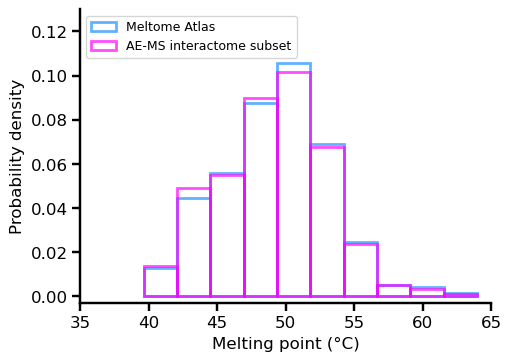

In [7]:
fs = 12

# data
meltome_Tm = meltome.loc[meltome["meltome-fit-R2"] >= 0.9, "meltome-melting-point"].dropna()
anyi_Tm    = nodes.loc[nodes["meltome-fit-R2"] >= 0.9, "meltome-melting-point"].dropna()

print(f"Median meltome melting temperature: {np.median(meltome_Tm)}")
print(f"Median ANYI meltome melting temperature: {np.median(anyi_Tm)}")

# width, height in inches
fig, ax = plt.subplots(figsize=(5, 3.5), constrained_layout=True)

ax.hist(meltome_Tm, histtype="bar", facecolor="none", edgecolor="dodgerblue",
        label="Meltome Atlas", density=True, linewidth=2, alpha=0.7)
ax.hist(anyi_Tm, histtype="bar", facecolor="none", edgecolor="magenta",
        label="AE-MS interactome subset", density=True, linewidth=2, alpha=0.7)

ax.legend(fancybox=True, fontsize=fs-3, loc="upper left")
ax.spines[['right', 'top']].set_visible(False)
spine_lw = 1.75
tick_lw  = 1.75
tick_len = 6

# spines (axes lines)
ax.spines["left"].set_linewidth(spine_lw)
ax.spines["bottom"].set_linewidth(spine_lw)

# ticks (marks) + tick-label padding
ax.tick_params(axis="both", which="both",
               width=tick_lw, length=tick_len,
               labelsize=fs, pad=3)
ax.set_xlabel("Melting point (°C)", fontsize=fs)
ax.set_ylabel("Probability density", fontsize=fs)
ax.set_xticks([35, 40, 45, 50, 55, 60, 65])
ax.set_yticks([0, 0.02, 0.04, 0.06, 0.08, 0.10, 0.12])
ax.tick_params(labelsize=fs)

ax.set_xlim(35, 65)
ax.set_ylim(-0.003, 0.13)

fig.savefig("1b.pdf", dpi=300)
plt.show()
plt.close(fig)

* bootstrap confidence intervals (B = 1_000_000) for the median, mean, min, and max melting temperature in the two sets
* print N for each category
* anyi dataset and partitions, to be used for later plots/tables: median, mean, min, max with 95% confidence intervals for the following partitions:
* 1. full interactome dataset meeting filtering criteria (melting point R2 >= 0.90)
* 2. hubs
* 3. non-hubs
* 4. phosphorylated based on: UniProt annotations + proteomeXchange gold-standard annotations
* 5. not phoshorylated based on absence of evidence in UniProt + proteomeXchange
* 6. phosphorylated + hub
* 7. non-phosphorylated + hub
* 8. phoshorylated + non-hub
* 9. non-phosphorylated + non-hub

In [8]:
summary_df, subsets = summarize_meltome_by_subset(
    nodes,
    B=1_000_000,
    ci=95,
    r2_thresh=0.90,
    random_state=27,
    show_progress=True,
)

# Print your per-category summary (includes median + CI fields)
with pd.option_context("display.max_columns", None, "display.width", 200):
    print(summary_df)

Bootstrapping: 100%|████████| 1000000/1000000 [00:23<00:00, 41667.16it/s]


                             n       mean  mean_ci_low  mean_ci_high  median  median_ci_low  median_ci_high    min  min_ci_low  min_ci_high    max  max_ci_low  max_ci_high
category                                                                                                                                                                   
1_all_filtered            1649  49.071407    48.881947     49.261086  49.300         49.040           49.56  39.63       39.63        41.21  63.97       61.66        63.97
2_hubs                     269  46.445799    45.974981     46.928700  45.650         44.680           47.13  41.01       41.01        41.43  61.77       57.38        61.77
3_non_hubs                1380  49.583210    49.387681     49.778754  49.720         49.560           49.95  39.63       39.63        41.22  63.97       61.66        63.97
4_phosphorylated          1330  49.055707    48.843835     49.267556  49.265         48.960           49.53  41.21       41.21        41.39 

In [10]:
stats = bootstrap_ci_stats(meltome_Tm, B=1_000_000, ci=95, random_state=27, show_progress=True)

Bootstrapping: 100%|████████| 1000000/1000000 [00:44<00:00, 22364.56it/s]


In [11]:
stats

{'n': 1920,
 'mean': 49.220890625,
 'mean_ci_low': 49.04586458333333,
 'mean_ci_high': 49.39585416666667,
 'median': 49.465,
 'median_ci_low': 49.27,
 'median_ci_high': 49.66,
 'min': 39.63,
 'min_ci_low': 39.63,
 'min_ci_high': 41.01,
 'max': 63.97,
 'max_ci_low': 61.88,
 'max_ci_high': 63.97}

/tmp/ipykernel_20090/4154506284.py:280: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([40, 45, 50, 55, 60, 65, 70], fontsize=fs)


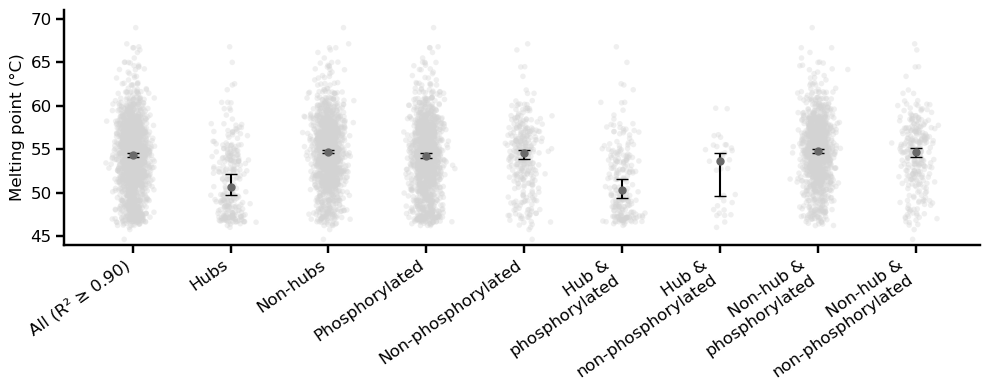

                 group_a                   group_b   n_a   n_b         U       p_value      p_adj_bh reject_fdr_0.05
0                 2_hubs                3_non_hubs   269  1380  101718.0  7.739804e-32  6.191843e-31            True
3      6_phospho_and_hub      8_phospho_and_nonhub   233  1097   66063.0  4.374674e-31  1.749870e-30            True
4      6_phospho_and_hub  9_not_phospho_and_nonhub   233   283   18391.0  5.188513e-18  1.383603e-17            True
5  7_not_phospho_and_hub      8_phospho_and_nonhub    36  1097   13583.5  1.424134e-03  2.848269e-03            True
6  7_not_phospho_and_hub  9_not_phospho_and_nonhub    36   283    3680.5  6.709864e-03  1.073578e-02            True
2      6_phospho_and_hub     7_not_phospho_and_hub   233    36    3353.0  5.302371e-02  7.069829e-02           False
7   8_phospho_and_nonhub  9_not_phospho_and_nonhub  1097   283  160016.0  4.229172e-01  4.833340e-01           False
1       4_phosphorylated      5_not_phosphorylated  1330   319  

In [16]:
# create panel 1c
plot_meltome_median_ci(subsets, summary_df, jitter_sd=0.08, alpha_points=0.35, fontsize=12)

# Pairwise MWU + BH-FDR
tests_df = pairwise_mwu_tests(subsets, value_col="meltome-melting-point", alternative="two-sided")
with pd.option_context("display.max_rows", None, "display.width", 200):
    print(tests_df.sort_values(["p_adj_bh", "p_value"]))

# Optional: matrix for later heatmap (adjusted p-values)
p_adj_mat = make_symmetric_pvalue_matrix(tests_df, value_col="p_adj_bh")